# Multi-Agent Research

**Docker image**: `ml4t`

One research agent gives one answer with no way to tell a considered probability from a
lucky search. Running several is the cheapest available check, and it only works if they
disagree: three agents returning the same number are one agent charged for three times.

This notebook runs three copies of the agent from
[`04_research_agent`](04_research_agent.ipynb) on one question, in parallel, and looks at
what came back. Nothing distinguishes the three except their identifiers, which is the point:
no roles, no settings, nothing assigned to make them differ. Two things can still make them
differ anyway - the model samples its replies, and each agent's searches return different
documents - and this run separates neither.

**What this run establishes, and what it does not.** The numbers below are one live capture
(`claude-sonnet-4`, Tavily search) taken on 2026-06-09 and replayed by default, so the
figures are the same whenever the notebook runs. One capture on one question is a
demonstration that a panel of identical agents is not degenerate. It is not an experiment:
nothing here varies temperature, retrieval, or question wording independently, so the spread
cannot be attributed to any of them. And the market's own probability was in every prompt,
which rules out reading the agents' closeness to the market as skill.

**Learning Objectives**:
- Run several agents concurrently and keep each one's conversation separately attributable
- Read a panel's timelines to tell genuine disagreement from one agent run three times
- Exclude agents that never produced a forecast before aggregating
- Show how far the assumed correlation moves an aggregate, relative to how far the agents
  are apart
- Say what a single dated capture of a multi-agent run does and does not establish

**Book Reference**: Chapter 24, Section 24.7 (Multi-Agent Forecasting Systems -
Agent Ensemble)

**Prerequisites**: [`04_research_agent`](04_research_agent.ipynb) (the agent),
[`05_aggregation_math`](05_aggregation_math.ipynb) (the aggregation rules).

In [1]:
"""Multi-Agent Research - parallel agents on one shared question."""

from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date, datetime

import matplotlib.pyplot as plt
import polars as pl
from agent_fixtures import get_chapter_clear_question
from agent_observability import (
    TRACES_DIR,
    RunTrace,
    merge_calls,
    replay_llm_calls,
    show_agents,
    trace_llm,
)
from agent_pipeline import neyman_extremize, neyman_extremize_weighted
from agent_providers import TokenUsage, create_llm_client
from agent_research import ResearchAgent, format_agent_summary
from agent_schemas import AgentForecastArtifact
from agent_tools import create_search_client
from IPython.display import Markdown, display

from utils.style import COLORS, add_message_title, format_pct_axis, show_with_alt

## Settings

`RUN_LIVE` left at `False` replays the pinned capture named below and makes no API calls.
Setting it to `True` forecasts a current question against live search and live models, which
costs money and will not reproduce these numbers; a prediction-market question moves under
you, and once it resolves it has to be swapped for a current one of the same kind.

`N_AGENTS` is how many copies to run on the live path. Three is enough for a spread to be
visible and small enough to be cheap; the replay uses however many the capture holds.

`MAX_STEPS` and `MAX_SEARCH_RESULTS` are the per-agent turn budget and search width from
[`04_research_agent`](04_research_agent.ipynb). Open models tend to search more before
committing, so raise `MAX_STEPS` if agents start hitting the budget without forecasting.

`NEYMAN_CORRELATION` is the pairwise correlation assumed when the panel is aggregated. It is
the input nothing here measures, and the sensitivity section further down is what says how
much rests on it.

`LLM_PROVIDER` is empty so the factory picks the first provider whose key is set; the cell
below reports which provider the capture used. Setting it to `"openrouter"` with
`OPENROUTER_MODEL="deepseek/deepseek-v4-pro"` drives an open model instead. `"mock"` returns
a constant forecast and is a smoke test, not a reproduction of this run.

In [2]:
RUN_LIVE = False
PINNED_TRACE = "06_multi_agent_research_20260609T141413Z_9fc4a2655471.json"
LLM_PROVIDER = ""
N_AGENTS = 3
MAX_STEPS = 5
MAX_SEARCH_RESULTS = 5
NEYMAN_CORRELATION = 0.3

## Setup

All three agents share one model client and one search client. Each gets a distinct
`agent_id` and nothing else: the same prompt, the same tools, the same sampling temperature.
Nothing is built in to make them disagree. Two channels remain open: the model's own
sampling, and the different documents each agent's searches return. The timelines below show
the second; nothing here separates the two.

The question is `CHAPTER_CLEAR_QUESTION` from `agent_fixtures.py`, *"Will the US enter a
recession by the end of 2026?"*, carrying the prediction-market probability recorded on
2026-06-09.

**That market probability was included in every prompt.** It is passed to `agent.run` as
`market_price` below, so each agent saw the market's answer before it searched. That makes
the comparison between the agents and the market circular, and it is why the market line in
the chart further down is labelled as context rather than as a benchmark. A run designed to
test the agents against the market would withhold it, as
[`04_research_agent`](04_research_agent.ipynb) does.

In [3]:
if RUN_LIVE:
    llm = create_llm_client(LLM_PROVIDER)
    search = create_search_client(LLM_PROVIDER)
    question = get_chapter_clear_question()
    provider_name = llm.model_name
    n_agents = N_AGENTS
    captured_on = date.today().isoformat()
else:
    pinned_run = RunTrace.load(TRACES_DIR / PINNED_TRACE)
    question = pinned_run.question_obj()
    provider_name = pinned_run.provider
    n_agents = len(pinned_run.agents)
    captured_on = datetime.fromisoformat(pinned_run.created_at).date().isoformat()

mode = "live" if RUN_LIVE else f"replay of a capture recorded {captured_on}"
print(f"Mode:         {mode}")
print(f"Provider:     {provider_name}")
print(f"Question:     {question.question}")
print(f"Market p_yes: {question.current_market_price}")
print(f"Agents:       {n_agents}")

Mode:         replay of a capture recorded 2026-06-09
Provider:     claude-sonnet-4-20250514
Question:     Will the US enter a recession by the end of 2026?
Market p_yes: 0.175
Agents:       3


## Running the Agents in Parallel

Each agent spends most of its time waiting on a network call, so running them one after
another wastes the whole panel's latency. A `ThreadPoolExecutor` gives each its own thread;
they share the model client and the search client, so both have to be safe under concurrent
calls. Anthropic's and Tavily's clients are. A provider whose client is not would need
construction inside the worker rather than outside it.

Each agent gets its own tracer wrapping the shared client. That is what keeps the captured
conversations attributable: one tracer across three threads would interleave three agents'
prompts into one log with no way to separate them afterwards. The per-agent logs are merged
once the pool has drained.

In [4]:
def run_agent(agent_id: str):
    """Run one research agent under its own tracer, returning both."""
    tracer = trace_llm(llm, label=agent_id)
    agent = ResearchAgent(
        llm=tracer,
        search=search,
        agent_id=agent_id,
        max_steps=MAX_STEPS,
        max_search_results=MAX_SEARCH_RESULTS,
    )
    return agent.run(question, market_price=question.current_market_price), tracer

The live path submits one task per agent. The replay path rehydrates the three saved
artifacts and their conversations instead, and every display cell below reads the same
objects either way.

In [5]:
artifacts: list[AgentForecastArtifact] = []

if RUN_LIVE:
    tracers = []
    with ThreadPoolExecutor(max_workers=N_AGENTS) as pool:
        futures = {pool.submit(run_agent, f"agent_{i}"): i for i in range(N_AGENTS)}
        for future in as_completed(futures):
            artifact, tracer = future.result()
            artifacts.append(artifact)
            tracers.append(tracer)
    llm_calls = merge_calls(*tracers)
else:
    artifacts = pinned_run.agent_artifacts()
    llm_calls = pinned_run.call_log()

# Threads finish in whatever order they finish; sort so the display is stable.
artifacts.sort(key=lambda a: a.agent_id)

# The replay is a fixed record. These fail closed if the named trace changes underneath.
if not RUN_LIVE:
    assert [a.p_yes for a in artifacts] == [0.12, 0.22, 0.22]
    assert len(llm_calls) == 12

## What Each Agent Returned

Probability, confidence, sentiment, and how much evidence each one gathered getting there.
The last two columns are worth as much as the first: two agents landing on the same
probability after two searches and after six searches did not do the same thing.

In [6]:
total_tokens = TokenUsage()
for a in artifacts:
    total_tokens = total_tokens + a.token_usage

panel_df = pl.DataFrame(
    [
        {
            "agent_id": a.agent_id,
            "p_yes": round(a.p_yes, 3),
            "confidence": round(a.confidence, 3),
            "sentiment": a.sentiment.value,
            "queries": a.search_queries_made,
            "sources": a.sources_consulted,
        }
        for a in artifacts
    ]
)
print(f"Market price shown to the agents: {question.current_market_price:.1%}")
print(f"Total tokens across the panel:    {total_tokens.total_tokens:,}\n")
panel_df

Market price shown to the agents: 17.5%
Total tokens across the panel:    57,908



agent_id,p_yes,confidence,sentiment,queries,sources
str,f64,f64,str,i64,i64
"""agent_0""",0.12,0.76,"""strongly_bearish""",3,15
"""agent_1""",0.22,0.56,"""bearish""",3,15
"""agent_2""",0.22,0.56,"""bearish""",3,15


The market line is drawn as context rather than as a benchmark, for the reason given above:
every agent was shown it.

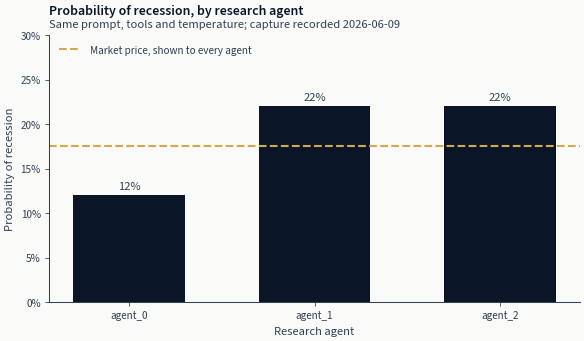

In [7]:
probabilities = panel_df["p_yes"].to_list()
probability_range = max(probabilities) - min(probabilities)

fig, ax = plt.subplots()
bars = ax.bar(
    panel_df["agent_id"].to_list(),
    probabilities,
    color=COLORS["blue"],
    width=0.6,
)
ax.axhline(
    question.current_market_price,
    color=COLORS["amber"],
    linestyle="--",
    linewidth=1.5,
    label="Market price, shown to every agent",
)
ax.bar_label(bars, labels=[f"{value:.0%}" for value in probabilities], padding=3)
ax.set_xlabel("Research agent")
ax.set_ylabel("Probability of recession")
ax.set_ylim(0, max(probabilities) + 0.08)
format_pct_axis(ax)
add_message_title(
    ax,
    "Probability of recession, by research agent",
    subtitle=f"Same prompt, tools and temperature; capture recorded {captured_on}",
)
ax.legend(loc="upper left")
show_with_alt(
    fig,
    "Bar chart with one bar per research agent, each labelled with the probability that agent "
    "returned, and a dashed horizontal line at the market price every agent was shown. Two of "
    "the bars are the same height and sit just above the market line; the third is much "
    "shorter and sits well below it.",
)

## Reading the Agents, Not the Aggregate

The table gives each agent's answer and none of its reasoning. `show_agents` renders the full
captured timeline for all three: every query, the documents it returned with title, date, URL
and a snippet, and the untruncated rationale, key findings and uncertainties. Each artifact
carries this in its `traces`, the `AgentTrace` records built in
[`04_research_agent`](04_research_agent.ipynb).

Read side by side, the timelines answer the question the bar chart cannot. Three agents
reaching similar numbers by different search paths is three observations. Three agents
pulling the same documents and reasoning in step is one observation printed three times, and
aggregating it produces confidence that nothing earned. The second case is what a panel of
identical agents drifts toward, and it is worth checking before any aggregation is trusted.

In [8]:
print(show_agents(artifacts))

  AGENT_0  ·  p_yes=0.12  confidence=0.76  sentiment=strongly_bearish  evidence=high
  searches=3  sources=15  tokens=12,662
  Step 1 · SEARCH  "US GDP growth forecast 2025 2026 recession indicators economic outlook"
      1. [?] U.S. outlook for 2026 - Indiana Business Research Center
         https://www.ibrc.indiana.edu/ibr/2025/outlook/national.html
         The IBR is a publication of the Indiana Business Research Center at
         IU's Kelley School of Business. *Recent developments in the U.S. and
         global economy present a complex and evolving picture for
         policymakers and business leaders. While our current readings of
         headline growth rema…
      2. [?] Economic Outlook U.S. Q2 2026: Curb Your Enthusia
         https://www.spglobal.com/ratings/en/regulatory/article/economic-outlook-us-q2-2026-curb-your-enthusiasm-s101676533
         [Current Oil Price Surge To Weigh On Growth](https://www.spglobal.com
         /ratings/en/regulatory/article/economic-ou

In [9]:
probability_text = ", ".join(f"{value:.2f}" for value in probabilities)
display(
    Markdown(
        f"**This run**: the three agents returned {probability_text}, a range of "
        f"{probability_range:.2f} on a question where the market stood at "
        f"{question.current_market_price:.1%}. That range is one observation from one capture. "
        "It says the panel is not degenerate; it does not say how large the spread would be on "
        "another question, another day, or with a different model."
    )
)

**This run**: the three agents returned 0.12, 0.22, 0.22, a range of 0.10 on a question where the market stood at 17.5%. That range is one observation from one capture. It says the panel is not degenerate; it does not say how large the spread would be on another question, another day, or with a different model.

## Aggregating the Panel

Three ways to turn three probabilities into one, from
[`05_aggregation_math`](05_aggregation_math.ipynb):

| Method | What it assumes |
|---|---|
| Simple mean | Nothing beyond the forecasts themselves |
| Neyman | A pairwise correlation, supplied rather than estimated |
| Weighted Neyman | That correlation, plus that the confidence values mean something |

Only artifacts that actually produced a forecast may enter any of the three. An agent that
exhausted its step budget carries the loop's fallback probability, and averaging that in
would pull the panel toward even odds on the strength of an agent that never answered.

In [10]:
answered = [a for a in artifacts if a.forecast_produced]
if not answered:
    raise RuntimeError("no agent produced a forecast; there is nothing to aggregate")

panel_probabilities = [a.p_yes for a in answered]
panel_confidences = [a.confidence for a in answered]

simple_mean = sum(panel_probabilities) / len(panel_probabilities)
result_neyman = neyman_extremize(panel_probabilities, base=0.5, correlation=NEYMAN_CORRELATION)
result_weighted = neyman_extremize_weighted(
    panel_probabilities, panel_confidences, base=0.5, correlation=NEYMAN_CORRELATION
)

print(f"Agents that produced a forecast: {len(answered)} of {len(artifacts)}")

pl.DataFrame(
    [
        {
            "method": "Simple mean",
            "aggregate": round(simple_mean, 3),
            "d": None,
            "n_eff": None,
        },
        {
            "method": "Neyman",
            "aggregate": round(result_neyman.extremized_probability, 3),
            "d": round(result_neyman.extremization_factor, 3),
            "n_eff": round(result_neyman.effective_n, 2),
        },
        {
            "method": "Weighted Neyman",
            "aggregate": round(result_weighted.extremized_probability, 3),
            "d": round(result_weighted.extremization_factor, 3),
            "n_eff": round(result_weighted.effective_n, 2),
        },
    ]
)

Agents that produced a forecast: 3 of 3


method,aggregate,d,n_eff
str,f64,f64,f64
"""Simple mean""",0.187,null,null
"""Neyman""",0.071,1.369,1.88
"""Weighted Neyman""",0.063,1.363,1.86


Both Neyman variants sit further from the base rate than the mean, which is what
extremization does. The gap between them is the whole contribution of the confidence
weights, and those weights are a function of how far each probability sits from even odds
rather than of anything measured, so the two lines being close is not reassurance.

## How Much the Correlation Assumption Decides

$\rho$ is the one input to Neyman extremization that nothing in this run measures, and it is
the input the answer is most sensitive to. Sweeping it over the same three forecasts shows
how much of the aggregate is evidence and how much is assumption.

In [11]:
correlation_rows = []
for rho in [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]:
    r = neyman_extremize(panel_probabilities, base=0.5, correlation=rho)
    rw = neyman_extremize_weighted(
        panel_probabilities, panel_confidences, base=0.5, correlation=rho
    )
    # The reported aggregate is clamped into [0.01, 0.99]. Recovering the value before the
    # clamp from the same result - the mean, the base rate and the diversity factor it used -
    # is what shows when the clamp is carrying the answer.
    unclamped = 0.5 + r.extremization_factor * (r.raw_probability - 0.5)
    correlation_rows.append(
        {
            "correlation": rho,
            "neyman": round(r.extremized_probability, 3),
            "before the clamp": round(unclamped, 3),
            "weighted_neyman": round(rw.extremized_probability, 3),
            "shift_from_mean": round((r.extremized_probability or 0) - simple_mean, 3),
        }
    )
correlation_df = pl.DataFrame(correlation_rows)
correlation_df

correlation,neyman,before the clamp,weighted_neyman,shift_from_mean
f64,f64,f64,f64,f64
0.0,0.01,-0.043,0.01,-0.177
0.1,0.01,0.005,0.01,-0.177
0.3,0.071,0.071,0.063,-0.116
0.5,0.116,0.116,0.109,-0.07
0.7,0.15,0.15,0.142,-0.037
0.9,0.176,0.176,0.169,-0.011


The `before the clamp` column is the one to read first. This panel sits far enough below the
base rate that the formula, credited with three near-independent observations, returns a
**negative** probability, and `neyman_extremize` floors it. Where the two columns differ, the
reported aggregate is the floor rather than the method's answer, and the sensitivity curve
below is flat there for that reason and no other.

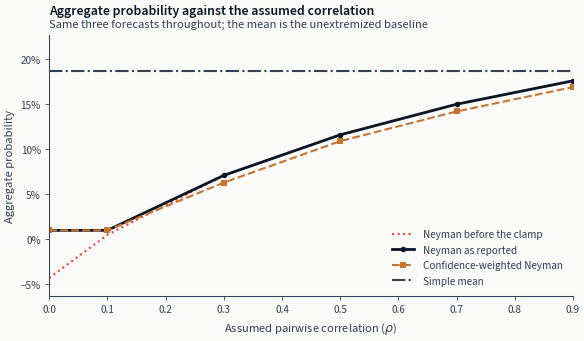

In [12]:
rho_values = correlation_df["correlation"].to_list()

unclamped_values = correlation_df["before the clamp"].to_list()

fig, ax = plt.subplots()
ax.plot(
    rho_values,
    unclamped_values,
    ":",
    color=COLORS["negative"],
    linewidth=1.5,
    label="Neyman before the clamp",
)
ax.plot(
    rho_values,
    correlation_df["neyman"].to_list(),
    "o-",
    color=COLORS["blue"],
    linewidth=2,
    label="Neyman as reported",
)
ax.plot(
    rho_values,
    correlation_df["weighted_neyman"].to_list(),
    "s--",
    color=COLORS["copper"],
    linewidth=1.5,
    label="Confidence-weighted Neyman",
)
ax.axhline(
    simple_mean,
    color=COLORS["neutral"],
    linestyle="-.",
    linewidth=1.5,
    label="Simple mean",
)
ax.set_xlabel(r"Assumed pairwise correlation ($\rho$)")
ax.set_ylabel("Aggregate probability")
ax.set_xlim(0, 0.9)
ax.set_ylim(min(unclamped_values) - 0.02, simple_mean + 0.04)
format_pct_axis(ax)
add_message_title(
    ax,
    "Aggregate probability against the assumed correlation",
    subtitle="Same three forecasts throughout; the mean is the unextremized baseline",
)
ax.legend(loc="lower right")
show_with_alt(
    fig,
    "Line chart of the aggregate probability against the assumed pairwise correlation, from "
    "independent to nearly identical. Both reported series rise steadily toward the horizontal "
    "line marking the unextremized mean, and both run flat at the independent end. The dotted "
    "line showing the value before the clamp keeps falling there, below zero, which is what "
    "the flat section is hiding.",
)

At the dependent end the panel is credited with barely more than one observation and the
aggregate settles onto the mean. At the independent end it is credited with three, the
formula pushes so far below the base rate that it leaves the unit interval, and what the
chart shows there is the floor. The agents' own forecasts never move along any of these
curves. Everything that does move is the assumption.

A clamp that carries the answer is worth naming rather than tolerating. It is not part of
the theory: it exists so the function always returns something a downstream consumer can
treat as a probability, and where it binds, the method has failed on this panel rather than
answered it. The reading to take from the left of this chart is that a three-agent panel this
far from even odds, under an independence assumption, is mapped outside the unit interval by
this formula, which therefore has no answer to give: not that the aggregate is whatever the
floor happens to be set to, and not that these three agents are in fact correlated.

Nothing in this run estimates $\rho$, and the confidence values feeding the weighted variant
are the extremity heuristic from [`04_research_agent`](04_research_agent.ipynb) rather than
measured skill. So the mean is the number to report, and the curve is what says how much
would be at stake in estimating the correlation properly.

## What the Next Stages Receive

Debate and supervisor reconciliation do not read the artifacts directly. They read this
summary: the agent's id, its probability and confidence, the opening of its rationale, and,
where the model enumerated any, its first few key findings. None of these three rationales
enumerates anything - all three are continuous prose - so no findings block appears below,
which is what [`04_research_agent`](04_research_agent.ipynb) means when it says the field
records how the model chose to present its reasons. Everything else - the full search trail,
the evidence, the uncertainties - stays in the record and out of the next prompt, which is a
context budget decision as much as a design one.

In [13]:
all_summaries = "\n\n---\n\n".join(format_agent_summary(a) for a in artifacts)
print(all_summaries)

Agent: agent_0
Probability (p_yes): 0.12
Confidence: 0.76
Rationale: Multiple forecasts show positive GDP growth for 2025-2026: Indiana Business Research Center forecasts 1.8% real GDP growth in 2026, Deloitte expects 4% business investment growth, and Fed officials pr

---

Agent: agent_1
Probability (p_yes): 0.22
Confidence: 0.56
Rationale: Based on current economic conditions and historical base rates, the US economy shows resilience with strong 2024 performance (2.5-2.9% GDP growth), low unemployment near 4%, and inflation approaching 

---

Agent: agent_2
Probability (p_yes): 0.22
Confidence: 0.56
Rationale: Based on professional forecaster surveys showing continued GDP growth expectations for 2025-2026, Fed projections indicating gradual economic expansion, and historical base rates showing US recessions


## Search Execution Audit

Rolling every agent's search steps into one table shows the panel's evidence-gathering at a
glance: who asked what, and how much came back. Queries appearing in more than one agent's
rows are shared retrieval, which is one of the two things that could explain agreement; the
table shows the overlap and does not, on its own, attribute the spread to it.

In [14]:
audit_df = pl.DataFrame(
    [
        {
            "agent_id": a.agent_id,
            "step": t.step,
            "query": t.query,
            "results": len(t.results),
        }
        for a in artifacts
        for t in a.traces
        if t.action == "search"
    ]
)
audit_df

agent_id,step,query,results
str,i64,str,i64
"""agent_0""",1,"""US GDP growth forecast 2025 20…",5
"""agent_0""",2,"""US recession probability 2025 …",5
"""agent_0""",3,"""Federal Reserve interest rates…",5
"""agent_1""",1,"""US economic indicators 2024 20…",5
"""agent_1""",2,"""US recession probability 2025 …",5
"""agent_1""",3,"""US economic base rates recessi…",5
"""agent_2""",1,"""US economic indicators 2024 20…",5
"""agent_2""",2,"""US recession probability 2025 …",5
"""agent_2""",3,"""historical US recession freque…",5


Two properties of the record are worth measuring rather than assuming, and the cell below
measures both. How many of the saved prompts carried the market's own probability, and how
many retrieved results carry a publication date.

In [15]:
search_results = [
    result for artifact in artifacts for trace in artifact.traces for result in trace.results
]
dated_sources = sum(result.published is not None for result in search_results)
market_mentions = sum(f"{question.current_market_price:.3f}" in str(call) for call in llm_calls)

display(
    Markdown(
        f"**Replay audit**: {market_mentions} of {len(llm_calls)} saved model calls include "
        f"the market probability; {dated_sources} of {len(search_results)} retrieved results "
        "record a publication date."
    )
)

**Replay audit**: 12 of 12 saved model calls include the market probability; 0 of 45 retrieved results record a publication date.

Both counts bound what this run can be used for. Every prompt carried the market price, so
the agents were told the answer the market had reached before they searched, and their
closeness to it says nothing about their skill. No result carries a publication date, so
nothing establishes that a document was available before the question was asked; the trace
reproduces what the agents saw and cannot date it.

## Persisting the Full Run Trace

Auditing an agent means being able to reconstruct exactly what it saw and
said. `RunTrace.capture` bundles the question, the parameters, every agent's
structured artifact, the aggregation result, and the complete raw model
conversation (`llm_calls` - every prompt sent and every response received,
captured by the per-agent `TracingLLMClient`s above) into one object, and
`save()` writes it to `forecast_traces/` as JSON. That saved file is exactly
what the replay path above reloads: it is the durable record of this
point-in-time run, which a reviewer can reopen long after the live market and
web evidence have moved on. A live run (`RUN_LIVE = True`) writes a fresh trace
here; the default replay run reports the pinned trace it loaded instead of
overwriting it.

In [16]:
if RUN_LIVE:
    run = RunTrace.capture(
        notebook="06_multi_agent_research",
        provider=provider_name,
        question=question,
        params={
            "n_agents": N_AGENTS,
            "max_steps": MAX_STEPS,
            "max_search_results": MAX_SEARCH_RESULTS,
        },
        agents=artifacts,
        aggregation=result_neyman,
        final_probability=result_neyman.extremized_probability,
        notes="Parallel research agents on one pinned, market-aware question.",
        llm_calls=llm_calls,
    )
    trace_path = run.save()
    print(
        f"Saved {len(run.llm_calls)} model calls "
        f"({run.total_tokens():,} tokens) → {trace_path.relative_to(trace_path.parents[1])}"
    )
else:
    # Replay: report the pinned trace we loaded rather than writing a new file.
    run = pinned_run
    trace_path = TRACES_DIR / PINNED_TRACE
    print(
        f"Replayed {len(run.llm_calls)} model calls "
        f"({run.total_tokens():,} tokens) from {trace_path.name}"
    )

Replayed 12 model calls (57,908 tokens) from 06_multi_agent_research_20260609T141413Z_9fc4a2655471.json


## The Raw Conversation

The timeline above is the parsed trace. This is what the model actually received and sent.
For the first agent, `replay_llm_calls` prints each message in order - the system prompt, the
question, and every tool result fed back in - beside the untruncated JSON returned at each
step.

This is where an audit ends up when a forecast looks wrong. The parsed rationale, the search
queries and the probability are all derived from these responses, so a disagreement between
the summary and the source is settled here. Pass `content_chars=None` for the complete
payloads.

In [17]:
agent_0_calls = [c for c in llm_calls if c.label == "agent_0"]
print(replay_llm_calls(agent_0_calls, content_chars=600))

  CALL #0 [agent_0]  ·  claude-sonnet-4-20250514  ·  json_mode=True  ·  tokens in/out=254/26
------------------------------------------------------------------------------
  ▸ SYSTEM:
      You are a forecasting agent in a multi-agent forecasting system.
      Your job:
      1) Gather evidence by issuing web/news search queries when needed.
      2) Then produce a binary probability forecast for the question.
      You must follow the action schema exactly and output valid JSON only.
      You must not browse prediction market prices unless they are explicitly
      provided.
  ▸ USER:
      QUESTION:
      Will the US enter a recession by the end of 2026?
      MARKET CONTEXT:
      Resolves YES if US real GDP (seasonally adjusted annualized) contracts
      for two consecutive quarters between Q2 2025 and Q4 2026, or the NBER
      declares a recession dated within that window.
      MARKET IMPLIED PROBABILITY (p_yes):
      0.175
      NEXT ACTION SCHEMA (output JSON only):
      I

## Key Takeaways

1. **Identical agents diverge, and that is the panel's entire value.** Nothing distinguishes
   these three: same prompt, same tools, same client, same sampling temperature. Three
   different answers come out anyway, from the model's sampling and from what each agent's
   searches returned, in proportions this run does not separate.
2. **A panel is only worth aggregating if its members are worth aggregating separately.**
   Read the timelines before the aggregate. Agents converging by different routes is evidence;
   agents pulling identical documents and reasoning in step is one agent run three times, and
   the aggregate will report false confidence.
3. **Extremization moves the answer more than the panel does.** Sweeping the correlation
   assumption over the same three forecasts moves the aggregate further than the forecasts
   themselves are apart. With no estimate of that correlation, the mean is the number to
   report and the Neyman values are a sensitivity analysis around it.
4. **An agent handed the market's own probability is not an independent check on it.** This
   capture put the market price in every prompt, so the agents' proximity to it is not
   evidence about their skill.
5. **Parallelism is a thread pool and a per-agent tracer.** Agents share the model client and
   the search client, so both have to be safe under concurrent calls; each gets its own
   tracer, which is what keeps the captured conversations correctly attributed.

**Known limitations of what is built here.** One capture, one question, three agents: the
spread has no error bar and nothing establishes it would recur. The confidence values feeding
the weighted aggregate are the extremity heuristic from
[`04_research_agent`](04_research_agent.ipynb), not measured skill. No retrieved result
carries a publication date, so nothing here can be scored as a point-in-time forecast. And
the agents differ only by sampling: a panel built to be diverse would vary the model, the
search index, or the framing of the question.

**Next**: [`07_adversarial_debate`](07_adversarial_debate.ipynb) takes a panel that disagrees
and makes the disagreement do work, by having the agents argue the two sides.

**Book**: Section 24.7 presents multi-agent forecasting systems.